In [14]:
from sklearn.feature_extraction.text import CountVectorizer

v = CountVectorizer()
v.fit(["Thor Hathodawala is looking for a job"])
v.vocabulary_

{'thor': 5, 'hathodawala': 1, 'is': 2, 'looking': 4, 'for': 0, 'job': 3}

In [15]:
v = CountVectorizer(ngram_range=(1, 2))
v.fit(["Thor Hathodawala is looking for a job"])
v.vocabulary_

{'thor': 9,
 'hathodawala': 2,
 'is': 4,
 'looking': 7,
 'for': 0,
 'job': 6,
 'thor hathodawala': 10,
 'hathodawala is': 3,
 'is looking': 5,
 'looking for': 8,
 'for job': 1}

In [16]:
v = CountVectorizer(ngram_range=(1, 3))
v.fit(["Thor Hathodawala is looking for a job"])
v.vocabulary_

{'thor': 12,
 'hathodawala': 2,
 'is': 5,
 'looking': 9,
 'for': 0,
 'job': 8,
 'thor hathodawala': 13,
 'hathodawala is': 3,
 'is looking': 6,
 'looking for': 10,
 'for job': 1,
 'thor hathodawala is': 14,
 'hathodawala is looking': 4,
 'is looking for': 7,
 'looking for job': 11}

In [17]:
corpus = [
    "Thor ate pizza",
    "Loki is tall",
    "Loki is eating pizza"
]

In [18]:
import spacy

# Load english language model and create nlp object from it
nlp = spacy.load("en_core_web_sm")

def preprocess(text):
  # remove stop words and lemmatize the text
  doc = nlp(text)
  filtered_tokens = []
  for token in doc:
    if token.is_stop or token.is_punct:
      continue
    filtered_tokens.append(token.lemma_)
  return " ".join(filtered_tokens)

In [19]:
preprocess("Thor ate pizza")

'thor eat pizza'

In [20]:
preprocess("Loki is eating pizza")

'Loki eat pizza'

In [21]:
corpus_preprocessed = [preprocess(text) for text in corpus]
print(corpus_preprocessed)

['thor eat pizza', 'Loki tall', 'Loki eat pizza']


In [22]:
v = CountVectorizer(ngram_range=(1, 2))
v.fit(corpus_preprocessed)
v.vocabulary_

{'thor': 7,
 'eat': 0,
 'pizza': 5,
 'thor eat': 8,
 'eat pizza': 1,
 'loki': 2,
 'tall': 6,
 'loki tall': 4,
 'loki eat': 3}

In [23]:
v.transform(["Thor eat pizza"]).toarray()

array([[1, 1, 0, 0, 0, 1, 0, 1, 1]])

In [24]:
v.transform(["Hulk eat pizza"]).toarray()

array([[1, 1, 0, 0, 0, 1, 0, 0, 0]])

**Task:**

Use bag of n-grams for new category classification problem and train a mchine learning model that can categorize any news into one of folowing categories.



*   Business
*   Sports
*   Crime
*  Science


**Dataset**

Dataset Credits: https://www.kaggle.com/code/hengzheng/news-category-classifier-val-acc-0-65


In [25]:
import pandas as pd

df = pd.read_json("/content/news_dataset.json")
print(df.shape)

df.head()

(12695, 2)


,text,category
0,Watching Schrödinger's Cat Die University of C...,SCIENCE
1,WATCH: Freaky Vortex Opens Up In Flooded Lake,SCIENCE
2,Entrepreneurs Today Don't Need a Big Budget to...,BUSINESS
3,These Roads Could Recharge Your Electric Car A...,BUSINESS
4,Civilian 'Guard' Fires Gun While 'Protecting' ...,CRIME


In [26]:
df.category.value_counts()

,count
category,
BUSINESS,4254
SPORTS,4167
CRIME,2893
SCIENCE,1381


Balancing data

In [27]:
min_sample = 1381

df_business = df[df.category == "BUSINESS"].sample(min_sample, random_state=2022)
df_sport = df[df.category == "SPORTS"].sample(min_sample, random_state=2022)
df_crime = df[df.category == "CRIME"].sample(min_sample, random_state=2022)
df_science = df[df.category == "SCIENCE"].sample(min_sample, random_state=2022)

In [28]:
df_balanced = pd.concat([df_business, df_sport, df_crime, df_science], axis=0)
df_balanced.category.value_counts()

,count
category,
BUSINESS,1381
SPORTS,1381
CRIME,1381
SCIENCE,1381


Convert text category to a number

In [29]:
target = {'BUSINESS': 0, 'SPORT': 1, 'CRIME': 2, 'SCIENCE': 3}

df_balanced['category_num'] = df_balanced['category'].map({
    'BUSINESS': 0,
    'SPORTS': 1,
    'CRIME': 2,
    'SCIENCE': 3
})

df_balanced.head()

,text,category,category_num
11967,GCC Business Leaders Remain Confident in the F...,BUSINESS,0
2912,From the Other Side; an Honest Review from Emp...,BUSINESS,0
3408,"Mike McDerment, CEO of FreshBooks, Talks About...",BUSINESS,0
502,How to Market Your Business While Traveling th...,BUSINESS,0
5279,How to Leverage Intuition in Decision-making I...,BUSINESS,0


Build a model with original text(no pre processing)

In [30]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    df_balanced.text,
    df_balanced.category_num,
    test_size=0.2,
    stratify=df_balanced.category_num
    )

print("Train dataset shape:", X_train.shape)
print("\nTetst dataset shape:", X_test.shape)
X_train.head()

Train dataset shape: (4419,)

Tetst dataset shape: (1105,)


,text
7727,These Are The 7 Men Scheduled To Be Executed I...
1275,This Is The Great Barrier Reef Like You've Nev...
8621,"Jack O’Neill, Founder Of Iconic Surf Brand, Di..."
7860,They're Back
1540,3 Reasons To Be Angry About Equifax’s Data Bre...


In [31]:
print(y_train.value_counts())
print(f"\n{y_test.value_counts()}")

category_num
2    1105
3    1105
0    1105
1    1104
Name: count, dtype: int64

category_num
1    277
0    276
3    276
2    276
Name: count, dtype: int64


In [32]:
from sklearn.naive_bayes import MultinomialNB
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report

clf = Pipeline([
    ('vectorizer_bow', CountVectorizer()),
    ('Multi NB', MultinomialNB())
])

clf.fit(X_train, y_train)
y_pred = clf.predict(X_test)

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.78      0.90      0.84       276
           1       0.91      0.85      0.88       277
           2       0.88      0.91      0.89       276
           3       0.93      0.83      0.88       276

    accuracy                           0.87      1105
   macro avg       0.88      0.87      0.87      1105
weighted avg       0.88      0.87      0.87      1105



In [33]:
print(X_test[:5])
print(y_pred[:5])

4516    Huy Fong CEO Fears New Sriracha Rivals Heinz a...
3196    Bank Of America Touts Going Green But Funnels ...
8028    3 Myths of Leadership Development:  Part II Th...
4257                         The Real Bill for ObamaCare 
9801    After 5-Year Trek, NASA Spacecraft Juno Prepar...
Name: text, dtype: object
[0 0 0 0 3]


Using 1-gram and bigrams

In [34]:
# Create a pipeline object
clf = Pipeline([
    ('vectorizer_bow', CountVectorizer(ngram_range=(1, 2))),
    ('Multi NB', MultinomialNB())
])

# fit with X_train and y_train
clf.fit(X_train, y_train)

# get the predictions for X_test and store it in y_pred
y_pred = clf.predict(X_test)

# print the classfication report
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.69      0.91      0.78       276
           1       0.92      0.79      0.85       277
           2       0.88      0.88      0.88       276
           3       0.95      0.76      0.85       276

    accuracy                           0.84      1105
   macro avg       0.86      0.84      0.84      1105
weighted avg       0.86      0.84      0.84      1105



Use 1-gram to trigrams

In [37]:
# create a pipeline obl=ject
clf = Pipeline([
    ('vectorizer_bow', CountVectorizer(ngram_range=(1, 2))),
    ('Multi NB', MultinomialNB())
])

# fit with X_train and y_train
clf.fit(X_train, y_train)

# get the predictions for X_test and store it in y_pred
y_pred = clf.predict(X_test)

# print the classification report
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.69      0.91      0.78       276
           1       0.92      0.79      0.85       277
           2       0.88      0.88      0.88       276
           3       0.95      0.76      0.85       276

    accuracy                           0.84      1105
   macro avg       0.86      0.84      0.84      1105
weighted avg       0.86      0.84      0.84      1105



Use text preprocessing to remove stop wprds, punctuations and apply lemmatization

In [39]:
df_balanced['preprocessed_text'] = df_balanced['text'].apply(preprocess)
df_balanced.head()

,text,category,category_num,preprocessed_text
11967,GCC Business Leaders Remain Confident in the F...,BUSINESS,0,GCC Business leader remain confident Face Regi...
2912,From the Other Side; an Honest Review from Emp...,BUSINESS,0,Honest Review Employees wake morning love impo...
3408,"Mike McDerment, CEO of FreshBooks, Talks About...",BUSINESS,0,Mike McDerment CEO FreshBooks Talks give build...
502,How to Market Your Business While Traveling th...,BUSINESS,0,market business travel World recently amazing ...
5279,How to Leverage Intuition in Decision-making I...,BUSINESS,0,leverage intuition decision making feel safe r...


In [40]:
# train/test
X_train, X_test, y_train, y_test = train_test_split(
    df_balanced.preprocessed_text,
    df_balanced.category_num,
    test_size=0.2,
    stratify=df_balanced.category_num
    )
print(X_train.shape)
print(X_test.shape)

(4419,)
(1105,)


In [42]:
y_train.value_counts()

,count
category_num,
1,1105
0,1105
2,1105
3,1104


In [43]:
# Create a pipeline object
clf = Pipeline([
    ('vectorizer_bow', CountVectorizer(ngram_range=(1, 2))),
    ('Multi NB', MultinomialNB())
])

# fit with X_train and y_train]
clf.fit(X_train, y_train)

# get the predictions for X_test and store it in y_pred
y_pred = clf.predict(X_test)

# print the classification report
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.80      0.91      0.85       276
           1       0.90      0.87      0.89       276
           2       0.86      0.93      0.89       276
           3       0.93      0.76      0.84       277

    accuracy                           0.87      1105
   macro avg       0.87      0.87      0.87      1105
weighted avg       0.87      0.87      0.87      1105



Plot confusion matrix

Text(0.5, 1.0, 'Confusion Matrix')

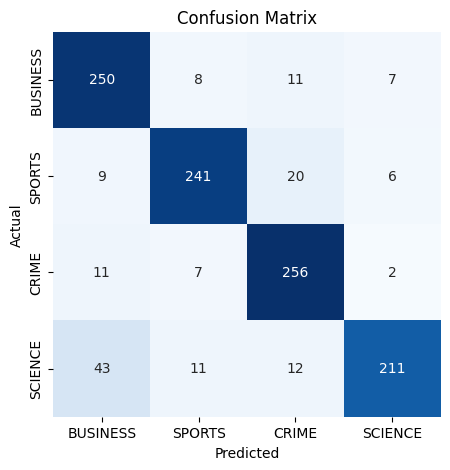

In [45]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)
fig, ax = plt.subplots(figsize=(5, 5))

# Get unique category names from df_balanced for xticklabels and yticklabels
target_names = df_balanced['category'].unique()

sns.heatmap(cm, annot=True, fmt='g', vmin=0, cmap='Blues', cbar=False,
            xticklabels=target_names, yticklabels=target_names)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")